In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}"
    })

plt.rcParams.update({'font.size': 20, 'axes.titlesize': 24, 'axes.labelsize': 20, 'legend.fontsize': 14, 'xtick.labelsize': 20, 'ytick.labelsize': 20})

seasons = {
        "DJF": [12, 1, 2],
        "MAM": [3, 4, 5],
        "JJA": [6, 7, 8],
        "SON": [9, 10, 11]
    }

In [2]:
def shift_phase_to_lst(phase_da, lon_da):
    """Shift phase from UTC to local solar time using longitude array.
    Args:
        phase_da (xr.DataArray): phase in UTC, dims (..., lat, lon)
        lon_da (xr.DataArray): longitude array, dims (lon,) or (..., lon)
    Returns:
        xr.DataArray: phase in local solar time (LST)
    """
    # Broadcast lon to match phase_da dimensions
    
    lon2d = xr.broadcast(phase_da, lon_da)[1]
    phase_lst = (phase_da + lon2d / 360 * 24) % 24
    return phase_lst

In [3]:
def fit_phase(peak, region, months, land_mask):

    peak = peak.assign_coords(lon=(((peak.lon + 360) % 360))).sortby('lon')
    if land_mask is not None:
        peak = peak.where(land_mask)

    seasons_ds = peak.sel(month=months)
    seasons_ds_region = seasons_ds.sel(lat=slice(region['lat'][0], region['lat'][1]), lon=slice(region['lon'][0], region['lon'][1]))

    # Convert to local solar time
    peak_lst = shift_phase_to_lst(seasons_ds_region, seasons_ds_region['lon'])

    # Convert to radians
    theta = 2 * np.pi * peak_lst/ 24 

    dim = ['month', 'lat', 'lon']
    nbins = 24

    weights = np.cos(np.deg2rad(peak_lst['lat']))
    sin_mean = np.sin(theta).weighted(weights).mean(dim=dim)
    cos_mean= np.cos(theta).weighted(weights).mean(dim=dim)
    theta_mean = np.arctan2(sin_mean, cos_mean)
    
    # rotate so mean = 0
    theta_rot = (theta - theta_mean + np.pi) % (2 * np.pi) - np.pi

    # convert back to hours
    theta_rot = (theta_rot * 24) / (2 * np.pi)

    # linear percentiles
    pct09 = theta_rot.quantile(0.9, dim=dim)
    pct01 = theta_rot.quantile(0.1, dim=dim)
    median = theta_rot.quantile(0.5, dim=dim)

    theta_mean = ((theta_mean * 24) / (2 * np.pi)) % 24

    #rotate back to that mean is at theta_mean and theta_rot goes from 0 to 24
    theta_rot = (theta_rot + theta_mean) % 24
    pct01 = (pct01 + theta_mean) % 24
    pct09 = (pct09 + theta_mean) % 24
    median = (median + theta_mean) % 24

    # histogram
    data = theta_rot.stack(points=("month", "lat", "lon")).values
    data = data[~np.isnan(data)]

    if data.size == 0:
        hist = np.zeros(nbins)
        bin_edges = np.linspace(0, 24, nbins + 1)
        print("Warning: no valid data after applying mask/selection in fit_phase")
    else:
        hist, bin_edges = np.histogram(data, bins=nbins, density=True)

    return hist, bin_edges, pct01, pct09, theta_mean, median

In [4]:
def amp_stats(ds, region, months, land_mask):
    ds = ds.assign_coords(lon=(((ds.lon + 360) % 360))).sortby('lon')
    if land_mask is not None:
        ds = ds.where(land_mask)
    ds_region = ds.sel(lat=slice(region['lat'][0], region['lat'][1]), lon=slice(region['lon'][0], region['lon'][1]))
    seasons_ds_region = ds_region.sel(month=months).mean(dim='month')
    # Weighted average
    weights = np.cos(np.deg2rad(seasons_ds_region['lat']))
    
    # Weighted mean over lat/lon/month
    seasons_ds_region_lst_avg = seasons_ds_region.weighted(weights).mean(dim=["lat", "lon"])
    seasons_ds_region_lst_90 = seasons_ds_region.weighted(weights).quantile(0.9, dim=["lat", "lon"]).drop_vars('quantile')
    seasons_ds_region_lst_10 = seasons_ds_region.weighted(weights).quantile(0.1, dim=["lat", "lon"]).drop_vars('quantile')
    
    return seasons_ds_region_lst_avg, seasons_ds_region_lst_90, seasons_ds_region_lst_10

In [5]:
fit_imerg = xr.open_dataset("/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_fit_utc.nc")
fit_ccic=xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_diurnal_fit_utc.nc')
fit_hcc = xr.open_dataset('/scratch/leko/HCC/CCIC_HCC_diurnal_fit_utc.nc')

In [6]:
amplitude_ccic = fit_ccic.diurnal_amplitude
amplitude_imerg = fit_imerg.diurnal_amplitude
amplitude_hcc = fit_hcc.diurnal_amplitude
peak_ccic = fit_ccic.diurnal_phase
peak_imerg = fit_imerg.diurnal_phase
peak_hcc = fit_hcc.diurnal_phase
coeff_ccic = fit_ccic.diurnal_fit_coeff_of_determination
coeff_imerg = fit_imerg.diurnal_fit_coeff_of_determination



In [7]:
high_coeff_ccic = coeff_ccic >= 0.6
high_coeff_imerg = coeff_imerg >= 0.6

In [8]:
lsm = xr.open_dataset('/data/s5/users/lara/diurnal-cycles/topo_r360x180.nc').topo
lsm = lsm.interp_like(amplitude_ccic, method="nearest")

In [9]:
regions = {
    "Tropics": {"lat": (-20, 20), "lon": (0, 360)},
    "Subtropics":{"lat": (35, 60), "lon": (0, 360)},
}

In [10]:
land = lsm > 0
ocean = lsm <= 0

In [11]:
winter = [12,1,2]
summer = [6,7,8]
all_months = range(1,13)

## Land

In [12]:
# Threshold

region = regions["Tropics"]

tiwp_mean = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018.nc').tiwp.mean(dim='hour_of_day')
imerg_mean = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023.nc').pr.mean(dim='hour_of_day')

# Define area
tiwp_mean_tropical_land = tiwp_mean.sel(lat=slice(region['lat'][0], region['lat'][1])).where(land)

# Weighted average
weights = np.cos(np.deg2rad(tiwp_mean_tropical_land['lat']))
# no weights
weights.name = "weights"

threshold_tiwp = tiwp_mean.weighted(weights).quantile(0.1)
non_arid_tiwp = tiwp_mean.mean(dim = 'month') > threshold_tiwp.values
print("threshold_tiwp:", threshold_tiwp.values)

threshold_imerg = imerg_mean.weighted(weights).quantile(0.1)
non_arid_imerg = imerg_mean.mean(dim = 'month') > threshold_imerg.values
print("threshold_imerg:", threshold_imerg.values)

threshold_tiwp: 0.0002196543733826703
threshold_imerg: 0.0023775964944132044


In [13]:
amplitude_ccic_tropics_land = amp_stats(amplitude_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)
amplitude_imerg_tropics_land = amp_stats(amplitude_imerg, regions['Tropics'], all_months, land & non_arid_imerg)

# Table

In [12]:
tiwp_mean = xr.open_dataset('/data/s5/users/lara/master_thesis/data/ccic/CCIC_TIWP_diurnal_climatology_2018.nc').tiwp.mean(dim='hour_of_day')
imerg_mean = xr.open_dataset('/scratch/leko/IMERG/IMERG_1_deg_diurnal/IMERG_diurnal_climatology_2018_2023.nc').pr.mean(dim='hour_of_day')


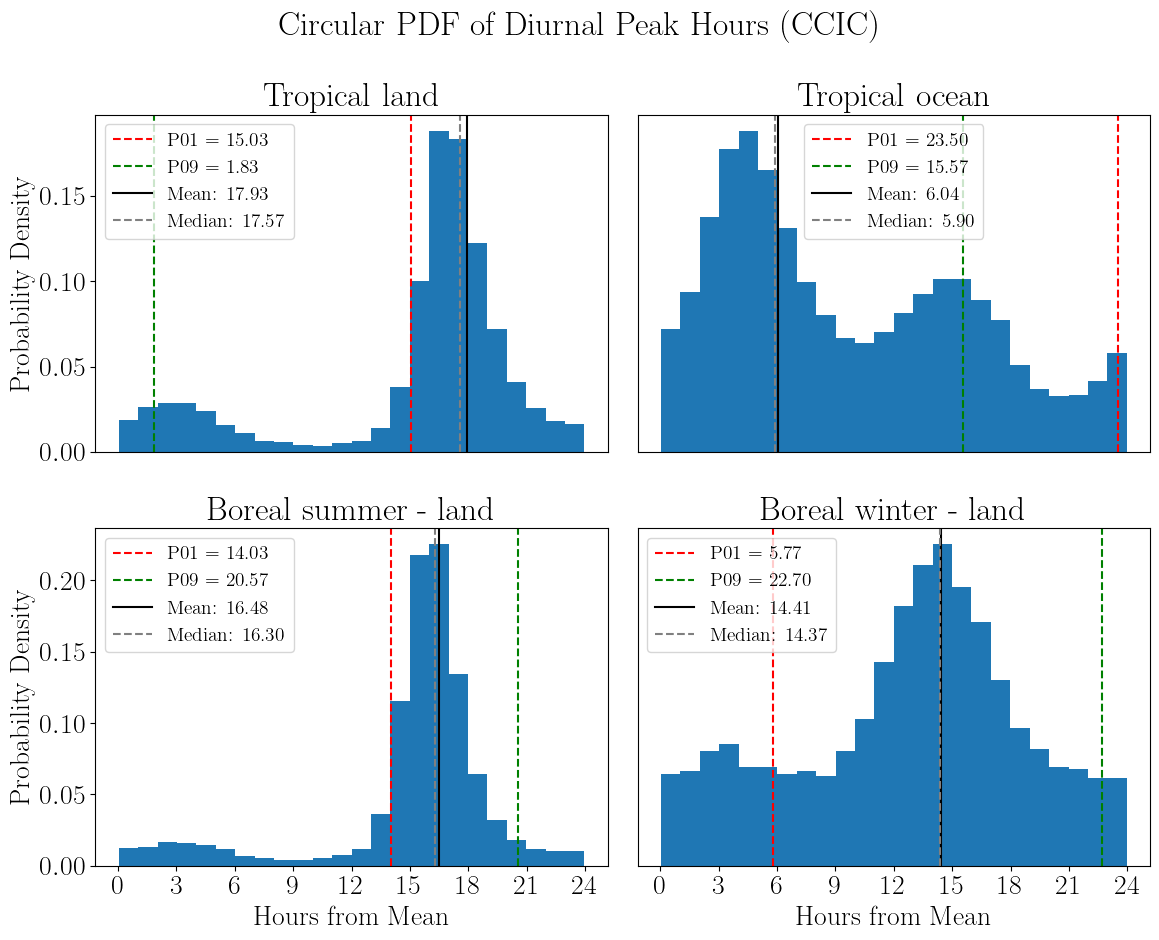

In [17]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
ax = axes.flatten()
for i in range(4):
    if i ==0:
        region = regions['Tropics']
        months = all_months
        threshold = land & non_arid_tiwp
        region_name = 'Tropical land'
    elif i == 1:
        region = regions['Tropics']
        months = all_months
        threshold = ocean
        region_name = 'Tropical ocean'
    elif i == 2:
        region = regions['Subtropics']
        months = summer
        threshold = land
        region_name = 'Boreal summer - land'
    else:
        region = regions['Subtropics']
        months = winter
        threshold = land
        region_name = 'Boreal winter - land'
    hist_ccic, bin_edges_ccic, pct01_ccic, pct09_ccic, theta_mean_ccic, median_ccic= fit_phase(peak_ccic, region, months, threshold)
    ax[i].bar(bin_edges_ccic[:-1], hist_ccic, width=bin_edges_ccic[1]-bin_edges_ccic[0], align='edge')
    # Only two decimal places for percentiles
    ax[i].axvline(pct01_ccic, color='red', linestyle='--',label = f'P01 = {pct01_ccic.values:.2f}')
    ax[i].axvline(pct09_ccic, color='green', linestyle='--', label = f'P09 = {pct09_ccic.values:.2f}')
    ax[i].axvline(theta_mean_ccic, color='black', linestyle='-', label = 'Mean: ' + f'{theta_mean_ccic.values:.2f}')
    ax[i].axvline(median_ccic, color='gray', linestyle='--', label = 'Median: ' + f'{median_ccic.values:.2f}')
    ax[i].set_title(f'{region_name}')
    # Only have x-ticks on bottom row
    if i < 2:
        ax[i].set_xticks([])
    else:
        ax[i].set_xticks(np.arange(0,25,3))
        ax[i].set_xlabel('Hours from Mean')
    # onhy have y-ticks on left column
    if i % 2 == 1:
        ax[i].set_yticks([])
    else:
        ax[i].set_ylabel('Probability Density')
    ax[i].legend()
plt.suptitle('Circular PDF of Diurnal Peak Hours (CCIC)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

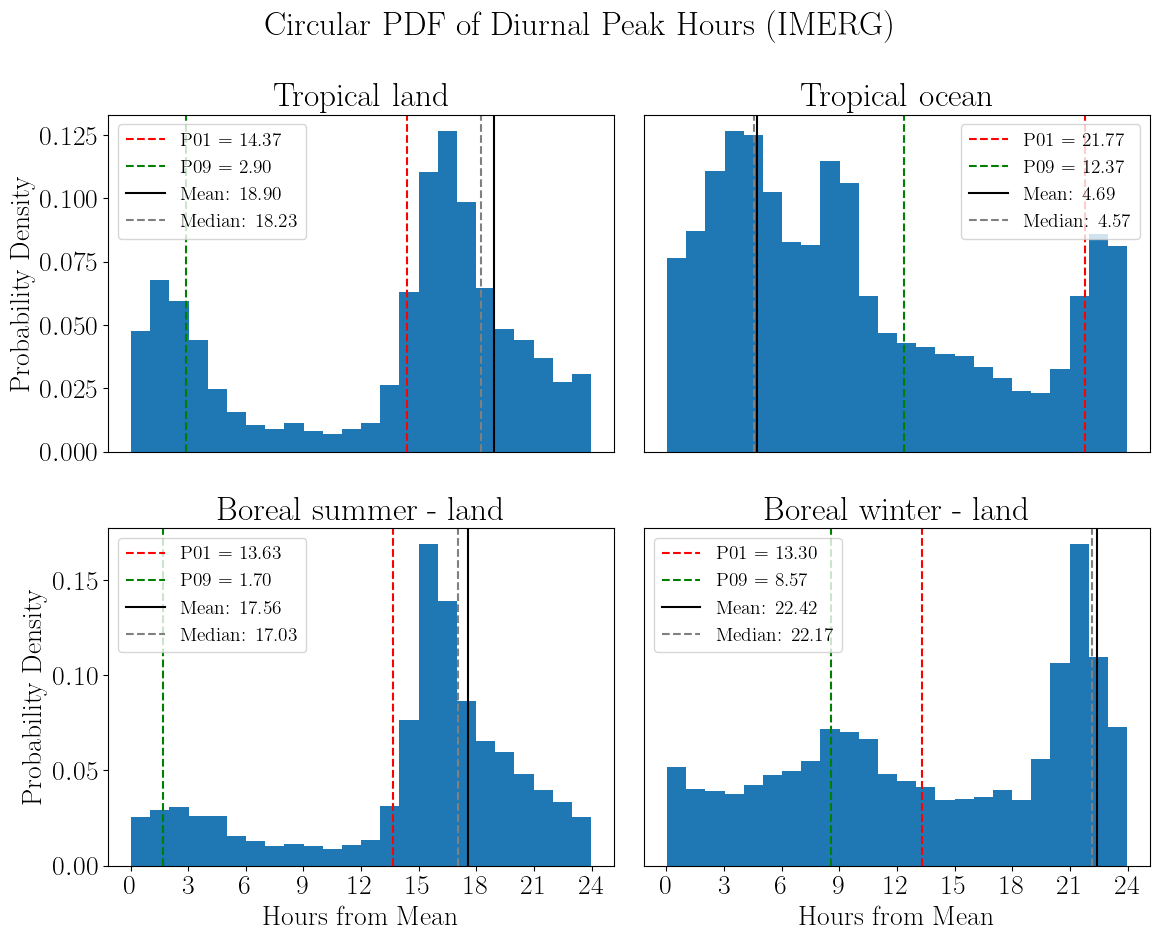

In [18]:
fig, axes = plt.subplots(2,2, figsize=(12,10))
ax = axes.flatten()
for i in range(4):
    if i ==0:
        region = regions['Tropics']
        months = all_months
        threshold = land & non_arid_imerg
        region_name = 'Tropical land'
    elif i == 1:
        region = regions['Tropics']
        months = all_months
        threshold = ocean
        region_name = 'Tropical ocean'
    elif i == 2:
        region = regions['Subtropics']
        months = summer
        threshold = land
        region_name = 'Boreal summer - land'
    else:
        region = regions['Subtropics']
        months = winter
        threshold = land
        region_name = 'Boreal winter - land'
    hist_imerg, bin_edges_imerg,pct01_imerg, pct09_imerg, theta_mean_imerg, median_imerg= fit_phase(peak_imerg, region, months, threshold)
    ax[i].bar(bin_edges_imerg[:-1], hist_imerg, width=bin_edges_imerg[1]-bin_edges_imerg[0], align='edge')
    # Only two decimal places for percentiles
    ax[i].axvline(pct01_imerg, color='red', linestyle='--',label = f'P01 = {pct01_imerg.values:.2f}')
    ax[i].axvline(pct09_imerg, color='green', linestyle='--', label = f'P09 = {pct09_imerg.values:.2f}')
    ax[i].axvline(theta_mean_imerg, color='black', linestyle='-', label = 'Mean: ' + f'{theta_mean_imerg.values:.2f}')
    ax[i].axvline(median_imerg, color='gray', linestyle='--', label = 'Median: ' + f'{median_imerg.values:.2f}')
    ax[i].set_title(f'{region_name}')
    # Only have x-ticks on bottom row
    if i < 2:
        ax[i].set_xticks([])
    else:
        ax[i].set_xticks(np.arange(0,25,3))
        ax[i].set_xlabel('Hours from Mean')
    # onhy have y-ticks on left column
    if i % 2 == 1:
        ax[i].set_yticks([])
    else:
        ax[i].set_ylabel('Probability Density')
    ax[i].legend()
plt.suptitle('Circular PDF of Diurnal Peak Hours (IMERG)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

\begin{table}[] 
    \begin{minipage}{\textwidth}
    \centering
    \begin{tabular}{p{3.5cm}|c|c|c|c|c|c}
        & \multicolumn{3}{c}{\textbf{CCIC diurnal amplitude}} \vline & \multicolumn{3}{c}{\textbf{CCIC peak time}}\\
        \textbf{period 2018 - 2023} & mean & 10$^{th}$ perc. & 90$^{th}$ perc. & mean & 10$^{th}$ perc. & 90$^{th}$ perc.\\
        \hline
        \hline
        \textbf{tropics ocean} & 0.092 & 0.007 & 0.182 &  &  &  \\
        \hline
        \textbf{tropics land}\footnote{We excluded arid areas (e.g. the southern part of the Sahara desert) with a mean fwp below XYZ here} & 0.307 & 0.081 & 0.543 &  &  &  \\
        \hline
        \textbf{boreal mid. lat. land DJF}& 0.034 & 0.012 & 0.058 &  &  &  \\
        \hline
        \textbf{boreal mid. lat. land JJA}& 0.118 & 0.043 &  0.210 &  &  &  \\

    \end{tabular}
    \end{minipage}

In [19]:
# convert decimal hours to hh:mm
def decimal_hours_to_hhmm(decimal_hours):
    hours = int(decimal_hours)
    minutes = int((decimal_hours - hours) * 60)
    return f"{hours:02d}:{minutes:02d}"

In [20]:
# tropics land
print("CCIC Amplitude Tropics Land:")
print("Mean: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[0].values)
print("10th Percentile: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[2].values)
print("90th Percentile: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[1].values)  
print("CCIC Peak Tropics Land:")
print("Mean: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[4].values))
print("10th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[2].values))
print("90th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, land & non_arid_tiwp)[3].values))
# tropics ocean
print("CCIC Amplitude Tropics Ocean:")
print("Mean: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, ocean )[0].values)
print("10th Percentile: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, ocean )[2].values) 
print("90th Percentile: ", amp_stats(amplitude_ccic, regions['Tropics'], all_months, ocean )[1].values)
print("CCIC Peak Tropics Ocean:")
print("Mean: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, ocean )[4].values))
print("10th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, ocean )[2].values))
print("90th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Tropics'], all_months, ocean )[3].values))

# boreal summer land
print("CCIC Amplitude Subtropics Land Summer:")
print("Mean: ", amp_stats(amplitude_ccic, regions['Subtropics'], summer, land )[0].values)
print("10th Percentile: ", amp_stats(amplitude_ccic, regions['Subtropics'], summer, land )[2].values)
print("90th Percentile: ", amp_stats(amplitude_ccic, regions['Subtropics'], summer, land )[1].values)  
# boreal summer land
print("CCIC Peak Subtropics Land Summer:")
print("Mean: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], summer, land )[4].values))
print("10th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], summer, land )[2].values))
print("90th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], summer, land )[3].values))

# boreal winter land
print("CCIC Amplitude Subtropics Land Winter:")
print("Mean: ", amp_stats(amplitude_ccic, regions['Subtropics'], winter, land )[0].values)
print("10th Percentile: ", amp_stats(amplitude_ccic, regions['Subtropics'], winter, land )[2].values)
print("90th Percentile: ", amp_stats(amplitude_ccic, regions['Subtropics'], winter, land )[1].values)  
# boreal winter land
print("CCIC Peak Subtropics Land Winter:")
print("Mean: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], winter, land )[4].values))
print("10th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], winter, land )[2].values))
print("90th Percentile: ", decimal_hours_to_hhmm(fit_phase(peak_ccic, regions['Subtropics'], winter, land )[3].values))

CCIC Amplitude Tropics Land:
Mean:  0.30832860728270156
10th Percentile:  0.08187488870075149
90th Percentile:  0.5453758047160433
CCIC Peak Tropics Land:
Mean:  17:55
10th Percentile:  15:01
90th Percentile:  01:49
CCIC Amplitude Tropics Ocean:
Mean:  0.09188032151301939
10th Percentile:  0.007461367514014043
90th Percentile:  0.18300536199884596
CCIC Peak Tropics Ocean:
Mean:  06:02
10th Percentile:  23:30
90th Percentile:  15:33
CCIC Amplitude Subtropics Land Summer:
Mean:  0.12192504127037143
10th Percentile:  0.04217811050981498
90th Percentile:  0.21952786229718357
CCIC Peak Subtropics Land Summer:
Mean:  16:28
10th Percentile:  14:01
90th Percentile:  20:33
CCIC Amplitude Subtropics Land Winter:
Mean:  0.03424386034631582
10th Percentile:  0.012282525051422221
90th Percentile:  0.05902874496287329
CCIC Peak Subtropics Land Winter:
Mean:  14:24
10th Percentile:  05:46
90th Percentile:  22:41


# Peak times - convective regions

In [12]:
regions_plot = {
    "Africa": {"color": "#c2896c", "lon": [15, 35], "lat": [-20, 5]},
    "Tropical Indian": {"color": "#8fa9b5", "lon": [55, 95], "lat": [-20, 0]},
    "Maritime Continent": {"color": "#bd5172", "lon": [95, 150], "lat": [-10, 10]},
    "North Pacific": {"color": "#797bd0", "lon": [140, 200], "lat": [15, 30]},
    "Tropical Pacific": {"color": "#77587e", "lon": [160, 200], "lat": [-20, 0]},
    "South America": {"color": "#c86c62", "lon": [285, 320], "lat": [-15, 0]},
}

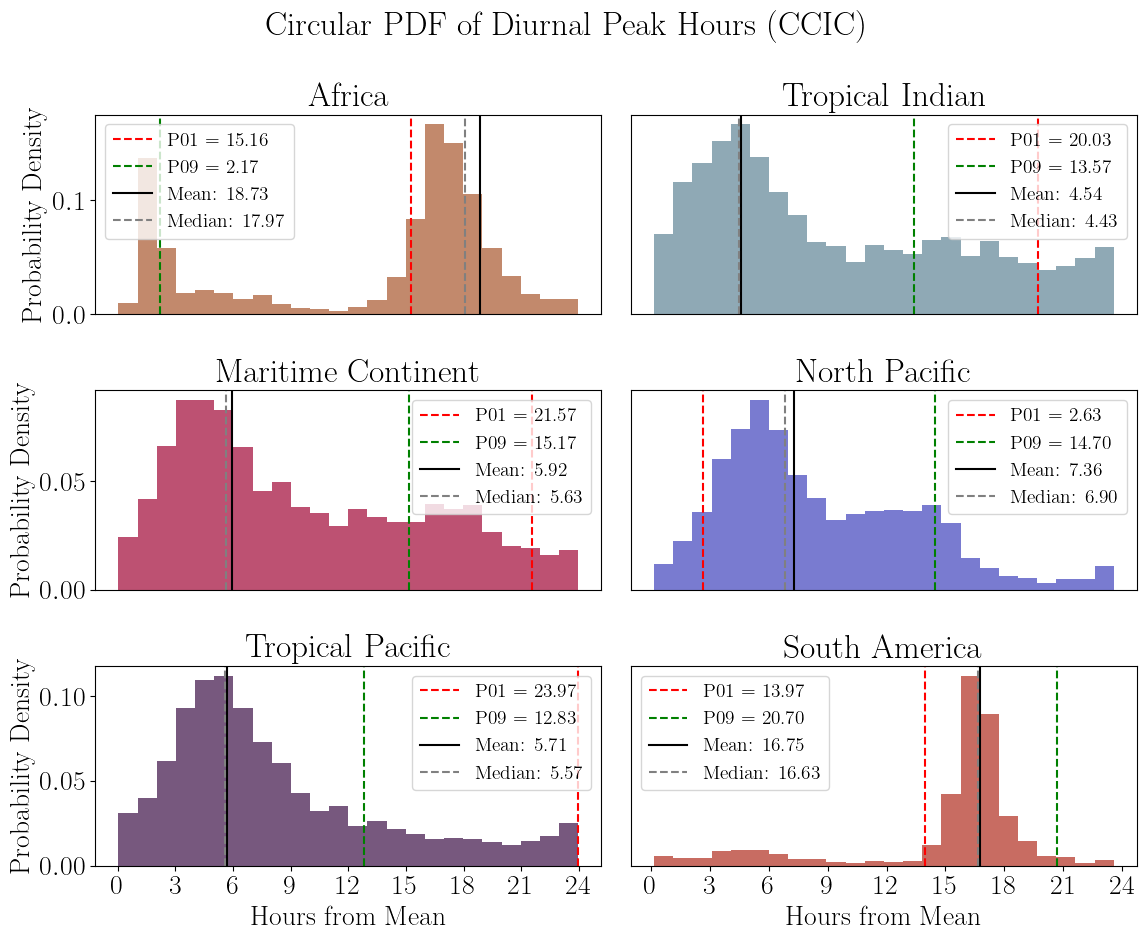

In [15]:
fig, axes = plt.subplots(3,2, figsize=(12,10))
ax = axes.flatten()
for region_name, region_info, i in zip(list(regions_plot.keys()), list(regions_plot.values()), range(len(regions_plot))):
    hist_ccic, bin_edges_ccic, pct01_ccic, pct09_ccic, theta_mean_ccic, median_ccic= fit_phase(peak_ccic, region_info, summer, None)
        
    ax[i].bar(bin_edges_ccic[:-1], hist_ccic, width=bin_edges_ccic[1]-bin_edges_ccic[0], align='edge', color=region_info['color'])
    # Only two decimal places for percentiles
    ax[i].axvline(pct01_ccic, color='red', linestyle='--',label = f'P01 = {pct01_ccic.values:.2f}')
    ax[i].axvline(pct09_ccic, color='green', linestyle='--', label = f'P09 = {pct09_ccic.values:.2f}')
    ax[i].axvline(theta_mean_ccic, color='black', linestyle='-', label = 'Mean: ' + f'{theta_mean_ccic.values:.2f}')
    ax[i].axvline(median_ccic, color='gray', linestyle='--', label = 'Median: ' + f'{median_ccic.values:.2f}')
    ax[i].set_title(f'{region_name}')
    # Only have x-ticks on bottom row
    if i < 4:
        ax[i].set_xticks([])
    else:
        ax[i].set_xticks(np.arange(0,25,3))
        ax[i].set_xlabel('Hours from Mean')
    # onhy have y-ticks on left column
    if i % 2 == 1:
        ax[i].set_yticks([])
    else:
        ax[i].set_ylabel('Probability Density')
    ax[i].legend()
plt.suptitle('Circular PDF of Diurnal Peak Hours (CCIC)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

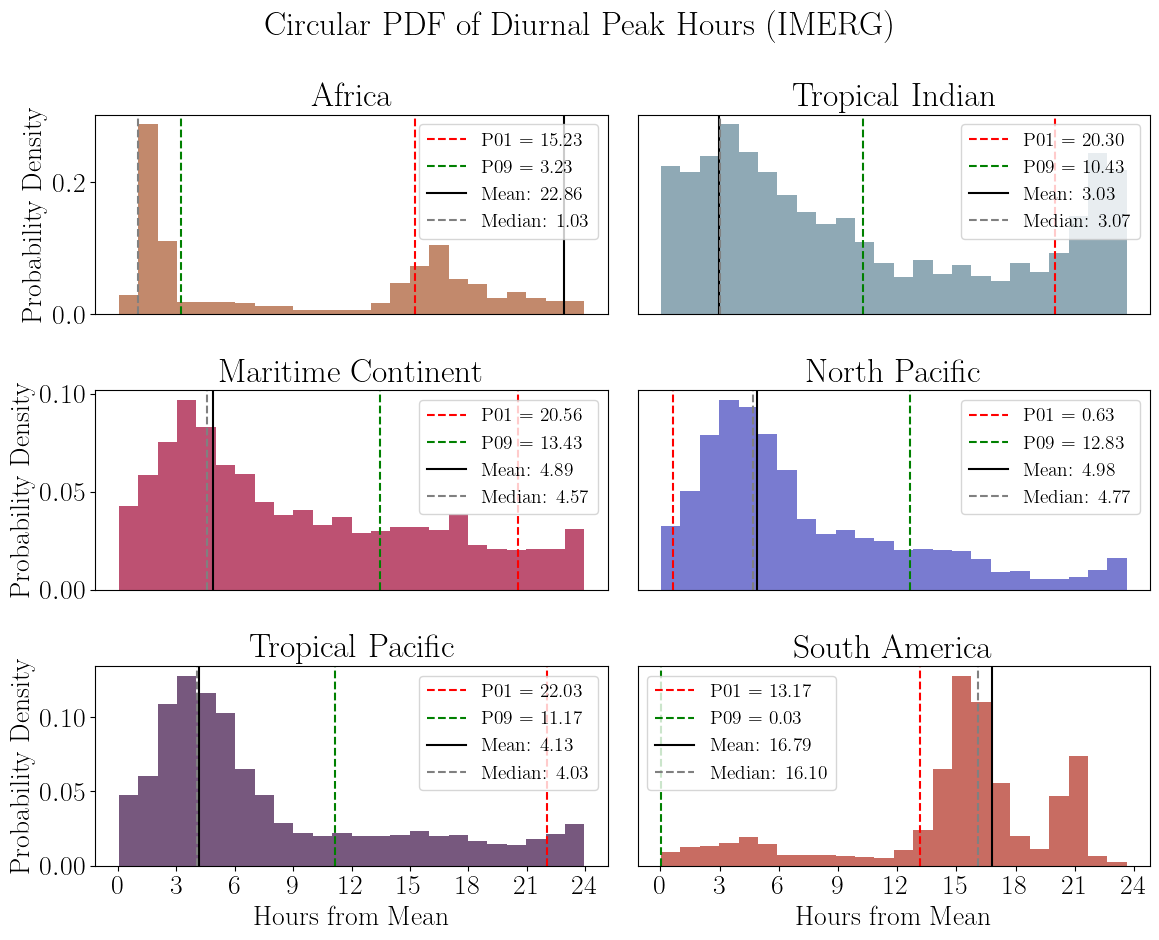

In [16]:
fig, axes = plt.subplots(3,2, figsize=(12,10))
ax = axes.flatten()
for region_name, region_info, i in zip(list(regions_plot.keys()), list(regions_plot.values()), range(len(regions_plot))):
    hist_imerg, bin_edges_imerg, pct01_imerg, pct09_imerg, theta_mean_imerg, median_imerg = fit_phase(peak_imerg, region_info, summer, None)
        
    ax[i].bar(bin_edges_imerg[:-1], hist_imerg, width=bin_edges_imerg[1]-bin_edges_imerg[0], align='edge', color=region_info['color'])
    # Only two decimal places for percentiles
    ax[i].axvline(pct01_imerg, color='red', linestyle='--',label = f'P01 = {pct01_imerg.values:.2f}')
    ax[i].axvline(pct09_imerg, color='green', linestyle='--', label = f'P09 = {pct09_imerg.values:.2f}')
    ax[i].axvline(theta_mean_imerg, color='black', linestyle='-', label = 'Mean: ' + f'{theta_mean_imerg.values:.2f}')
    ax[i].axvline(median_imerg, color='gray', linestyle='--', label = 'Median: ' + f'{median_imerg.values:.2f}')
    ax[i].set_title(f'{region_name}')
    # Only have x-ticks on bottom row
    if i < 4:
        ax[i].set_xticks([])
    else:
        ax[i].set_xticks(np.arange(0,25,3))
        ax[i].set_xlabel('Hours from Mean')
    # onhy have y-ticks on left column
    if i % 2 == 1:
        ax[i].set_yticks([])
    else:
        ax[i].set_ylabel('Probability Density')
    ax[i].legend()
plt.suptitle('Circular PDF of Diurnal Peak Hours (IMERG)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

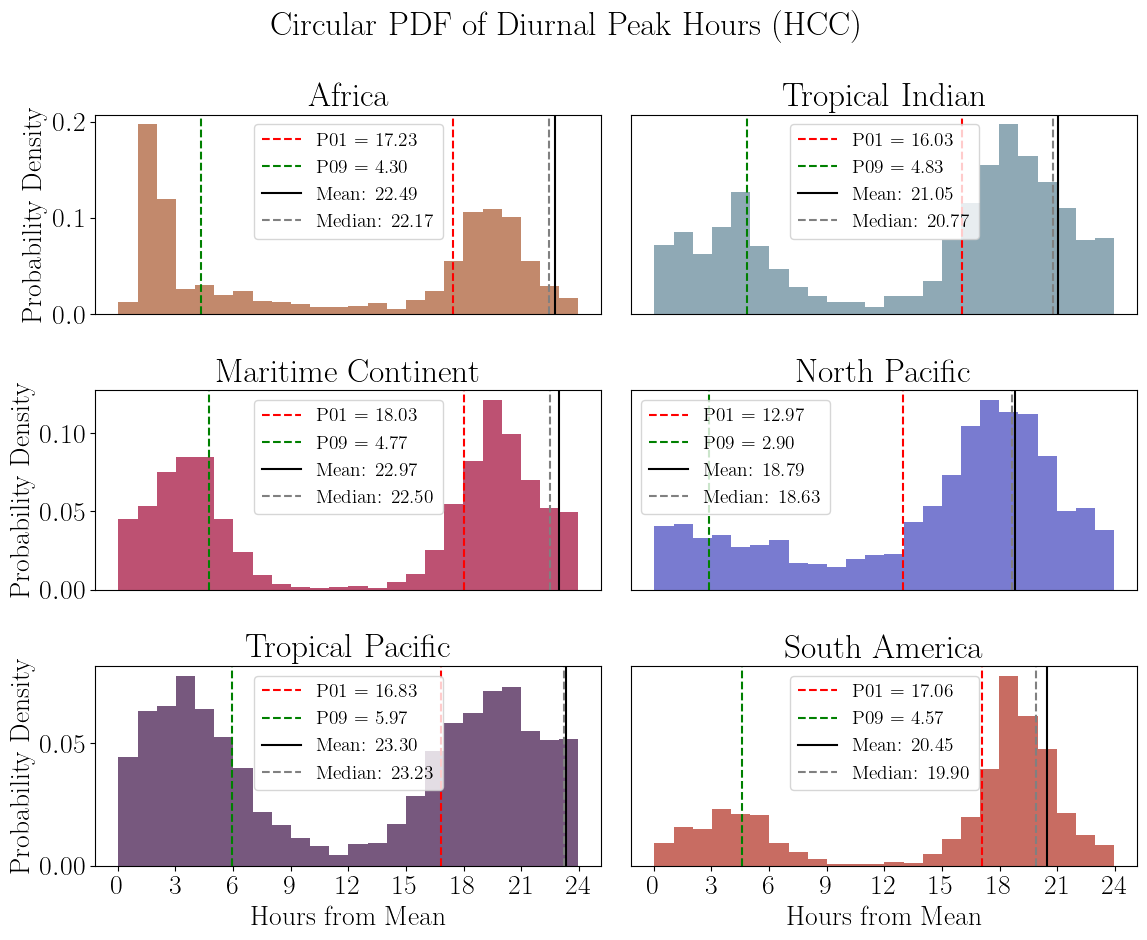

In [17]:
fig, axes = plt.subplots(3,2, figsize=(12,10))
ax = axes.flatten()
for region_name, region_info, i in zip(list(regions_plot.keys()), list(regions_plot.values()), range(len(regions_plot))):
    hist_imerg, bin_edges_imerg, pct01_imerg, pct09_imerg, theta_mean_imerg, median_imerg = fit_phase(peak_hcc, region_info, summer, None)
        
    ax[i].bar(bin_edges_imerg[:-1], hist_imerg, width=bin_edges_imerg[1]-bin_edges_imerg[0], align='edge', color=region_info['color'])
    # Only two decimal places for percentiles
    ax[i].axvline(pct01_imerg, color='red', linestyle='--',label = f'P01 = {pct01_imerg.values:.2f}')
    ax[i].axvline(pct09_imerg, color='green', linestyle='--', label = f'P09 = {pct09_imerg.values:.2f}')
    ax[i].axvline(theta_mean_imerg, color='black', linestyle='-', label = 'Mean: ' + f'{theta_mean_imerg.values:.2f}')
    ax[i].axvline(median_imerg, color='gray', linestyle='--', label = 'Median: ' + f'{median_imerg.values:.2f}')
    ax[i].set_title(f'{region_name}')
    # Only have x-ticks on bottom row
    if i < 4:
        ax[i].set_xticks([])
    else:
        ax[i].set_xticks(np.arange(0,25,3))
        ax[i].set_xlabel('Hours from Mean')
    # onhy have y-ticks on left column
    if i % 2 == 1:
        ax[i].set_yticks([])
    else:
        ax[i].set_ylabel('Probability Density')
    ax[i].legend()
plt.suptitle('Circular PDF of Diurnal Peak Hours (HCC)')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()